# Step 1: Clone

In [5]:
from __future__ import annotations
import csv, os, re, subprocess, time
from pathlib import Path
from typing import Optional, List

# -----------------------------
# Config (edit as needed)
# -----------------------------
WORK_ROOT    = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
URL_LIST_CSV = WORK_ROOT / "URL_List.csv"
CLONE_ROOT   = WORK_ROOT / "clonesV9.0"
MANIFEST_CSV = WORK_ROOT / "clones_manifestV9.0.csv"

WITH_SUBMODULES = False     # set True if you want submodules initialized/updated
WITH_LFS        = False     # set True if you need Git LFS objects
FETCH_PR_REFS   = True      # set False to skip GitHub PR heads

# Create dirs
WORK_ROOT.mkdir(parents=True, exist_ok=True)
CLONE_ROOT.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
DEFAULT_TIMEOUT = 1800  # 30 minutes for huge repos
GIT_ENV = {"GIT_TERMINAL_PROMPT": "0", "GIT_ASKPASS": ""}

def sh(cmd: List[str], cwd: Optional[Path] = None, check: bool = True,
       capture: bool = True, timeout: Optional[int] = DEFAULT_TIMEOUT) -> subprocess.CompletedProcess:
    env = os.environ.copy()
    env.update(GIT_ENV)
    return subprocess.run(cmd, cwd=cwd, check=check,
                          capture_output=capture, text=True,
                          timeout=timeout, env=env)

def sh_ok(cmd: List[str], cwd: Optional[Path] = None, timeout: Optional[int] = DEFAULT_TIMEOUT) -> str:
    cp = sh(cmd, cwd=cwd, check=True, capture=True, timeout=timeout)
    return cp.stdout

def repo_dir_name_from_url(url: str) -> str:
    u = url.strip()
    # SSH form: git@host:owner/repo(.git)
    m = re.match(r"^[^@]+@([^:]+):([^/]+)/(.+?)(?:\.git)?$", u)
    if m:
        owner, name = m.group(2), m.group(3)
        return f"{owner}__{name}"
    # https://host/owner/repo(.git)
    if "://" in u:
        base = u.split("://", 1)[1]
    else:
        base = u
    parts = [p for p in base.split("/") if p]
    if len(parts) >= 2:
        owner, name = parts[-2], parts[-1].removesuffix(".git")
        return f"{owner}__{name}"
    return base.replace("/", "__").removesuffix(".git")

def ensure_full_clone(url: str, dest_root: Path,
                      with_submodules: bool = False,
                      with_lfs: bool = False,
                      fetch_pr_refs: bool = True) -> Path:
    """
    Ensures a non-shallow clone with full history of all branches & tags.
    Optionally fetches GitHub PR heads to refs/remotes/origin/pr/*,
    initializes submodules, and fetches LFS objects.
    """
    dest_root.mkdir(parents=True, exist_ok=True)
    d = dest_root / repo_dir_name_from_url(url)

    if not (d.exists() and (d / ".git").exists()):
        # no-recurse-submodules avoids submodule cost unless requested later
        sh(["git", "clone", "--no-recurse-submodules", "--tags", url, str(d)],
           capture=False)
    else:
        # If repo exists, ensure origin URL is correct
        sh(["git", "remote", "set-url", "origin", url], cwd=d, check=False)

    # If shallow, unshallow
    cp = sh(["git", "rev-parse", "--is-shallow-repository"], cwd=d, check=False)
    if cp.returncode == 0 and cp.stdout.strip() == "true":
        sh(["git", "fetch", "--unshallow", "--tags"], cwd=d, capture=False)
    else:
        # Make sure we have tags even if already full
        sh(["git", "fetch", "--tags"], cwd=d, check=False, capture=False)

    # Fetch all branches under refs/heads/* and prune deleted ones
    sh(["git", "fetch", "origin", "--prune", "--tags",
        "+refs/heads/*:refs/remotes/origin/*", "--quiet"], cwd=d, check=False, capture=False)

    # Best-effort PR refs (GitHub); harmless if not present
    if fetch_pr_refs:
        sh(["git", "fetch", "origin",
            "+refs/pull/*/head:refs/remotes/origin/pr/*", "--quiet"], cwd=d, check=False, capture=False)

    # Optional: submodules
    if with_submodules:
        sh(["git", "submodule", "update", "--init", "--recursive"], cwd=d, capture=False)

    # Optional: LFS
    if with_lfs:
        # If git-lfs isn't installed, these will fail harmlessly due to check=False
        sh(["git", "lfs", "install"], cwd=d, check=False, capture=False)
        sh(["git", "lfs", "fetch", "--all"], cwd=d, check=False, capture=False)
        sh(["git", "lfs", "checkout"], cwd=d, check=False, capture=False)

    return d

def get_total_commits(repo_dir: Path) -> int:
    # Count across all refs reachable in the repository
    cp = sh(["git", "rev-list", "--all", "--count"], cwd=repo_dir, check=False)
    try:
        return int((cp.stdout or "0").strip() or "0")
    except Exception:
        return 0

# -----------------------------
# Main: FULL CLONE ONLY
# -----------------------------
assert URL_LIST_CSV.exists(), f"CSV not found: {URL_LIST_CSV}"

rows, ok, fail = [], 0, 0
with URL_LIST_CSV.open(newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        url = (row.get("repo_url") or "").strip()
        if not url:
            continue
        t0 = time.time()
        rec = {
            "repo_url": url,
            "dir": None,
            "status": "unknown",
            "seconds": None,
            "total_commits": None,
            "error": ""
        }
        try:
            d = ensure_full_clone(url, CLONE_ROOT,
                                  with_submodules=WITH_SUBMODULES,
                                  with_lfs=WITH_LFS,
                                  fetch_pr_refs=FETCH_PR_REFS)
            rec["dir"] = str(d)
            rec["total_commits"] = get_total_commits(d)
            rec["status"] = "ok"
            ok += 1
        except subprocess.CalledProcessError as e:
            rec["status"] = "error"
            rec["error"]  = (e.stderr or e.stdout or str(e)).strip()[:2000]
            fail += 1
        except Exception as e:
            rec["status"] = "error"
            rec["error"]  = str(e)[:2000]
            fail += 1

        rec["seconds"] = round(time.time() - t0, 2)
        rows.append(rec)
        print(f"[{rec['status']}] {url} -> {rec['dir']} ({rec['seconds']}s)  commits={rec['total_commits']}")

# Write manifest
MANIFEST_CSV.parent.mkdir(parents=True, exist_ok=True)
fieldnames = ["repo_url","dir","status","seconds","total_commits","error"]
with MANIFEST_CSV.open("w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(rows)

print(f"\nDone. OK={ok}, FAIL={fail}. Manifest: {MANIFEST_CSV}")


[ok] https://github.com/connectbot/connectbot -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3\clonesV9.0\connectbot__connectbot (6.63s)  commits=3640
[ok] https://github.com/robolectric/robolectric -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3\clonesV9.0\robolectric__robolectric (27.72s)  commits=21440
[ok] https://github.com/opendocument-app/OpenDocument.droid -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3\clonesV9.0\opendocument-app__OpenDocument.droid (12.64s)  commits=6083
[ok] https://github.com/maxpower47/PinDroid -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3\clonesV9.0\maxpower47__PinDroid (5.26s)  commits=1057
[ok] https://github.com/Rajawali/Rajawali -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3\clonesV9.0\Rajawali__Rajawali (17.48s)  commits=3065
[ok] https://github.com/cgeo/cgeo -> C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3\clonesV9.0\cgeo__cgeo (120.39s)  commits=73654
[ok] https://github.com/O

## Step 2: Mining 
add a baseline to read the repos from the begining not from the first change

In [ ]:
# Notebook-friendly miner (auto-runs) — ALIGNED WITH ORIGINAL YAML DETECTOR (adjusted w/ compiled triggers)
from __future__ import annotations

import csv, json, os, random, re, subprocess, sys, time, shutil
from concurrent.futures import ThreadPoolExecutor as PoolExecutor, as_completed
from datetime import datetime
from functools import lru_cache
from pathlib import Path
from typing import Dict, List, Optional, Set, Tuple, Iterable

# ===========================
# Config (EDIT THESE PATHS)
# ===========================
WORK_ROOT   = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
INPUT_CLONES = WORK_ROOT / "clonesV9.0"
OUTPUT_MINE  = WORK_ROOT / "mineV9.0"

# Cutoff (UTC). Used for default-branch head at/before and for censoring the last day window.
CUTOFF_ISO = "2025-08-10 23:59:59 +0000"

# Performance / behavior toggles
MAX_REPOS          = 0                     # 0 = all
MAX_WORKERS        = min(32, (os.cpu_count() or 8) * 2)
RESUME_IF_EXISTS   = True
SUPPRESS_EMPTY_ROWS= True
CAPTURE_EMPTY_GAPS = True
EMIT_NONE_STATE    = False

# Blob size guards
BLOB_MAX_SIZE = 2_000_000
HARD_MAX_SIZE = 5_000_000

# High-priority CI paths never skipped (even if large)
HIGH_PRIORITY_CI_PATHS = {
    ".github/workflows", ".gitlab-ci.yml", "azure-pipelines.yml",
    ".circleci/config.yml", ".bitrise.yml", ".travis.yml",
}

# ===========================
# Quick startup checks
# ===========================
def _failfast_checks():
    if shutil.which("git") is None:
        print("[fatal] Git not found in PATH. Install Git and/or add it to PATH.", file=sys.stderr)
        raise SystemExit(1)
    if not WORK_ROOT.exists():
        print(f"[fatal] WORK_ROOT does not exist: {WORK_ROOT}", file=sys.stderr)
        raise SystemExit(1)
    if not INPUT_CLONES.exists():
        print(f"[warn] INPUT_CLONES does not exist yet: {INPUT_CLONES}")
    OUTPUT_MINE.mkdir(parents=True, exist_ok=True)

_failfast_checks()
print("[ok] Pre-flight checks passed.")

# ===========================
# File classifiers
# ===========================
YAML_EXTS = (".yml", ".yaml")
GRADLE_NAMES = {"build.gradle", "build.gradle.kts", "settings.gradle", "settings.gradle.kts"}
GRADLE_EXTS = (".gradle", ".gradle.kts")
SCRIPT_EXTS = (".sh", ".bat", ".cmd", ".ps1")
CI_BUILD_SPECIAL = {"Jenkinsfile", ".travis.yml", "azure-pipelines.yml", ".gitlab-ci.yml", "circle.yml"}
XML_BUILD_FILES = {"pom.xml", "build.xml", "config.xml"}

def is_yaml(path: str) -> bool:
    return os.path.splitext(path)[1].lower() in YAML_EXTS or os.path.basename(path) in CI_BUILD_SPECIAL

def is_gradle(path: str) -> bool:
    name = os.path.basename(path)
    ext = os.path.splitext(path)[1].lower()
    return name in GRADLE_NAMES or ext in GRADLE_EXTS

def is_script(path: str) -> bool:
    ext = os.path.splitext(path)[1].lower()
    return ext in SCRIPT_EXTS or os.path.basename(path) in ("Jenkinsfile",)

def is_ci_xml_or_build_xml(path: str) -> bool:
    return os.path.basename(path).lower() in {n.lower() for n in XML_BUILD_FILES}

def is_relevant_file(path: str) -> bool:
    return is_yaml(path) or is_gradle(path) or is_script(path) or is_ci_xml_or_build_xml(path)

def is_high_priority_ci_path(path: str) -> bool:
    norm = path.replace("\\", "/")
    base = os.path.basename(norm)
    if base in HIGH_PRIORITY_CI_PATHS:
        return True
    for root in HIGH_PRIORITY_CI_PATHS:
        if norm.startswith(root.rstrip("/") + "/"):
            return True
    return False

# ===========================
# Regexes & Helpers (ALIGNED)
# ===========================

# -------- Comment stripping / normalization (from original approach) --------
COMMENT_LINE_RE = re.compile(r'(?m)^\s*(#|//|REM\b|::).*?$')

def strip_comments(raw: str) -> str:
    return COMMENT_LINE_RE.sub("", raw or "")

def normalize_block_keys(text: str) -> str:
    text = re.sub(r'(?mi)^\s*(script|run|command)\s*:\s*(?!\||>|\|\-)\s*(.+)$', r'\2', text)
    text = re.sub(r'(?mi)^\s*(script|run|command)\s*:\s*(\||>|\|\-)\s*$', '', text)
    text = re.sub(
        r'(?m)^(\s*)-\s*(?=(?:\./|\.\\|bash|sh|pwsh|powershell|gradle(?:w)?|adb|flutter|gcloud|saucectl|appcenter)\b)',
        r'\1',
        text
    )
    return text

IGNORE_GHA_ACTIONS_RE = re.compile(
    r'(?mi)^\s*uses\s*:\s*('
    r'docker/(?:setup-qemu-action|setup-buildx-action|build-push-action|login-action)'
    r'|actions/checkout'
    r'|docker/setup-qemu-action'
    r'|docker/setup-buildx-action'
    r')@.*$'
)
def strip_irrelevant_ci_lines(text: str) -> str:
    return IGNORE_GHA_ACTIONS_RE.sub('', text or '')

GHA_EXPR_RE = re.compile(r"\${{\s*[^}]+}}")
def pre_sanitize(text: str) -> str:
    return GHA_EXPR_RE.sub("", text or "")

# -------- Gradle command shapes & guards (from original) --------
GRADLE_PREFIX = (
    r'^\s*'
    r'(?:\S+=\S+\s+)*'
    r'(?:sudo\s+)?'
    r'(?:(?:bash|sh)\s+-c[l]?\s+[\'"]?)?'
    r'(?:[^#\n;]*?&&\s+)?'
    r'(?:cd\s+\S+\s+&&\s+)?'
    r'(?:\./|\.\\)?gradle(?:w)?(?:\.bat)?'
)
GRADLE_ANYWHERE = r'(?i)[^\n]*\bgradle(?:w)?(?:\.bat)?[^\n]*'
GRADLE_ANYWHERE_RE = re.compile(GRADLE_ANYWHERE)
GRADLE_BUILD_ACTION_RE = re.compile(r'(?mi)\buses\s*:\s*(gradle/gradle-build-action|gradle/actions/setup-gradle)@')

NON_TEST_PREFIX = r'(?:assemble|bundle|package|compile|merge|process|generate|install|uninstall|jacoco|lint|publish|sign|upload)'

SHELL_PREFIX = r'(?:\S+=\S+\s+)*(?:sudo\s+)?(?:(?:bash|sh|pwsh|powershell)\s+-c\s+[\'"]?)?(?:[^#\n;]*?&&\s+)?'

# -------- Device / env patterns (from original, adapted) --------
EMULATOR_LINE = rf'(?mi)^[^\n]*{SHELL_PREFIX}(?:\s|^)(?:(?:\./|\.\\)?(?:emulator)(?:\.exe)?)\b[^\n]*-avd\s+\S+'
ADB_WAIT_LINE = rf'(?mi)^[^\n]*{SHELL_PREFIX}adb\s+wait[- ]?for[- ]?device\b'
ADB_SERIAL_LINE = rf'(?mi)^[^\n]*{SHELL_PREFIX}adb\s+-s\s+(?:emulator-\d+|localhost:\d+|127\.0\.0\.1:\d+)'
REAL_DEVICE_LINE = rf'(?mi)^\s*adb\s+-s\s+(?!emulator-\d+\b)(?!localhost:\d+\b)(?!127\.0\.0\.1:\d+\b)\S+\b'

DEVICE_SOURCES = [
    ("Real_Device", "adb -s <serial> (physical)", [REAL_DEVICE_LINE]),

    # Emulator DIY / generic
    ("Emulator", "adb -s emulator-serial", [ADB_SERIAL_LINE]),
    ("Emulator", "adb wait-for-device",   [ADB_WAIT_LINE]),
    ("Emulator", "emulator -avd/@",       [EMULATOR_LINE]),
    ("Emulator", "android-wait-for-emulator", [r'(?mi)^\s*(?:\./)?android-wait-for-emulator\b']),
    ("Emulator", "start-emulator.sh",     [r'(?mi)^\s*start-emulator\.sh\b']),
    ("Emulator", "android create avd",    [r'\bandroid\b[^\n]*\bcreate\s+avd\b']),
    ("Emulator", "circleci android orb",  [
        r'(?mi)^\s*(?:-\s*)?android/start-emulator-and-run-tests\s*:',
        r'(?mi)^\s*system-image\s*:\s*system-images;android-\d+;google_apis;'
    ]),

    # Marketplace actions (subtype classifiers)
    ("Emulator", "reactivecircus runner", [r'(?mi)\buses\s*:\s*reactivecircus/android-emulator-runner@[\w\.\-]+']),
    ("Emulator", "malinskiy runner",      [r'(?mi)\buses\s*:\s*malinskiy/action-android/emulator-run-cmd@[\w\.\-]+']),

    # sys-img / avdmanager / sdkmanager
    ("Emulator", "sys-img component", [
        r'(?m)^\s*-\s*sys-img-[^\s]*-android-(?:\d+|\$[A-Z_][A-Z0-9_]*)\b',
        r'(?m)^\s*-\s*sys-img-[^\s]*-google_apis-[^\s]*(?:\d+|\$[A-Z_][A-Z0-9_]*)\b'
    ]),
    ("Emulator", "avdmanager", [r'(?m)^\s*\S*avdmanager\b']),
    ("Emulator", "sdkmanager system-images/emulator", [
        r'^\s*\S*sdkmanager\b[^\n"]*"system-images;android-(?:\d+|\$[A-Z_][A-Z0-9_]*)[^"\n]*"',
        r'^\s*\S*sdkmanager\b[^\n]*\bsystem-images;android-(?:\d+|\$[A-Z_][A-Z0-9_]*)\b',
    ]),

    # Other emulator actions (not ReactiveCircus/Malinskiy nor emulator.wtf)
    ("Emulator", "other gha emulator", [
        r'(?mi)^\s*uses\s*:\s*vgaidarji/android-github-actions-emulator@[\w\.\-]+',
        r'(?mi)^\s*uses\s*:\s*(?!reactivecircus/android-emulator-runner@)'
        r'(?!malinskiy/action-android/emulator-run-cmd@)'
        r'(?!emulator-wtf/run-tests@)'
        r'[\w\.-]+/[\w\./-]*android[\w\./-]*(?:\bemulator\b|\bavd\b)[\w\./-]*@[\w\.\-]+'
    ]),
]

def compile_any(patterns: List[str], flags=re.I | re.M) -> List[re.Pattern]:
    return [re.compile(p, flags) for p in patterns]

DEVICE_PATTERNS = [(grp, lbl, compile_any(pats)) for (grp, lbl, pats) in DEVICE_SOURCES]

# -------- Triggers (primary + anywhere) (from original) --------
TRIGGER_SOURCES_PRIMARY = [
    ("Gradle", "connectedAndroidTest",
     [rf'(?mi){GRADLE_PREFIX}[^\n\r]*\b(?:[:\w-]+:)*connectedandroidtest\b[^\n\r]*']),
    ("Gradle", "connected.*Android.*",
     [rf'''(?mix){GRADLE_PREFIX}[^\n\r]*\b(?:[:\w-]+:)*connected[a-z0-9:_-]*android[a-z0-9:_-]*test\b
         (?![^\n\r]*\b(?:{NON_TEST_PREFIX})[\w-]*androidtest\b)[^\n\r]*''']),
    ("Gradle", "connectedCheck",
     [rf'(?mi){GRADLE_PREFIX}[^\n\r]*\b(?:[:\w-]+:)*connectedcheck\b[^\n\r]*']),
    ("Gradle", "cAT shorthand",
     [rf'(?mi){GRADLE_PREFIX}[^\n\r]*\b(?:[:\w-]+:)*cAT\b[^\n\r]*']),
    ("Gradle", "deviceCheck",
     [rf'(?mi){GRADLE_PREFIX}[^\n\r]*\b(?:[:\w-]+:)*(?:devicecheck|alldevicechecks)\b[^\n\r]*']),

    # GMD (managed devices) invocation
    ("Gradle", "managedDevice AndroidTest",
     [rf'(?mi){GRADLE_PREFIX}[^\n\r]*\b(?!{NON_TEST_PREFIX})(?:manageddevice|device)[\w:-]*androidtest\b[^\n\r]*']),

    # Variants NOT assemble/baseline-only
    ("Gradle", "variant/device AndroidTest",
     [rf'''(?mix){GRADLE_PREFIX}[^\n\r]*\b(?:(?:[:\w-]+:)*) (?!{NON_TEST_PREFIX})(?!connected)(?!spoon)(?!marathon)
            [A-Za-z0-9][\w-]*androidtest\b[^\n\r]*''']),

    ("Gradle", "Spoon",    [rf'(?mi){GRADLE_PREFIX}[^\n\r]*\bspoon(?:\w*androidtest)?\b']),
    ("Gradle", "Marathon", [rf'(?mi){GRADLE_PREFIX}[^\n\r]*\bmarathon(?:\w*androidtest)?\b']),

    ("ADB", "am instrument", [r'(?mi)^[^\n]*\bam\s+instrument\b']),

    # 3P CLIs (instrumentation-only for FTL)
    ("Third_Party_Lab", "gcloud firebase (instr)",
     [r'(?mi)\bgcloud(?:\s+beta)?\s+firebase\s+test\s+android\s+run[^\n]*\b(--test\b|--type\s+instrumentation\b)']),
    ("Third_Party_Lab", "flank",     [r'(?mi)^[^\n]*\bflank\s+android\s+run\b']),
    ("Third_Party_Lab", "saucectl",  [r'(?mi)^[^\n]*\bsaucectl(?:\s+run)?\b']),
    ("Third_Party_Lab", "appcenter", [r'(?mi)^[^\n]*\bappcenter\s+test\s+run\s+android\b']),
    ("Third_Party_Lab", "emulator.wtf run",
     [r'(?mi)^\s*uses\s*:\s*emulator-wtf/run-tests@[\w\.\-]+', r'(?i)\bemulator\.wtf\b']),
]
TRIGGER_SOURCES_PRIMARY += [
    ("Gradle", "generateBaselineProfile",
     [rf'(?mi){GRADLE_PREFIX}[^\n\r]*\b(?:[:\w-]+:)*generate(?:\w*?)baselineprofile\b[^\n\r]*']),
    ("Gradle", "collectBaselineProfile",
     [rf'(?mi){GRADLE_PREFIX}[^\n\r]*\b(?:[:\w-]+:)*collect(?:\w*?)baselineprofile\b[^\n\r]*']),
    ("Gradle", "connectedBenchmarkAndroidTest",
     [rf'(?mi){GRADLE_PREFIX}[^\n\r]*\b(?:[:\w-]+:)*connectedbenchmarkandroidtest\b[^\n\r]*']),
]
TRIGGER_SOURCES_ANYWHERE = [
    ("Gradle", "connected (anywhere)", [
        rf'(?mix){GRADLE_ANYWHERE}\b(?:[:\w-]+:)*connected[a-z0-9:_-]*android[a-z0-9:_-]*test\b'
    ]),
    ("Gradle", "connectedAndroidTest (anywhere)",
     [rf'(?mi){GRADLE_ANYWHERE}\bconnectedandroidtest\b']),
    ("Gradle", "connectedCheck (anywhere)",
     [rf'(?mi){GRADLE_ANYWHERE}\b(?:[:\w-]+:)*connectedcheck\b']),
    ("Gradle", "managedDevice AndroidTest (anywhere)", [
        rf'''(?mix){GRADLE_ANYWHERE}\b(?:(?:[:\w-]+:)* (?!{NON_TEST_PREFIX})(?!connected)(?!spoon)(?!marathon)
           [A-Za-z0-9][\w-]*androidtest\b)'''
    ]),
    ("Gradle", "variant/device AndroidTest (anywhere)", [
        rf'''(?mix){GRADLE_ANYWHERE}\b(?:(?:[:\w-]+:)* (?!{NON_TEST_PREFIX})[\w-]*androidtest\b)'''
    ]),
    ("Gradle", "Spoon (anywhere)",    [rf'(?mi){GRADLE_ANYWHERE}\bspoon(?:\w*androidtest)?\b']),
    ("Gradle", "Marathon (anywhere)", [rf'(?mi){GRADLE_ANYWHERE}\bmarathon(?:\w*androidtest)?\b']),
]
TRIGGER_SOURCES_ANYWHERE += [
    ("Gradle", "generateBaselineProfile (anywhere)",
     [rf'(?mi){GRADLE_ANYWHERE}\bgenerate(?:\w*?)baselineprofile\b']),
    ("Gradle", "collectBaselineProfile (anywhere)",
     [rf'(?mi){GRADLE_ANYWHERE}\bcollect(?:\w*?)baselineprofile\b']),
    ("Gradle", "connectedBenchmarkAndroidTest (anywhere)",
     [rf'(?mi){GRADLE_ANYWHERE}\bconnectedbenchmarkandroidtest\b']),
]

# === NEW: compile trigger tables (fix) ===
TRIGGER_PATTERNS_PRIMARY  = [(grp, lbl, compile_any(pats)) for (grp, lbl, pats) in TRIGGER_SOURCES_PRIMARY]
TRIGGER_PATTERNS_ANYWHERE = [(grp, lbl, compile_any(pats)) for (grp, lbl, pats) in TRIGGER_SOURCES_ANYWHERE]

def any_match(patterns: Iterable, text: str) -> bool:
    # Hardened: if a raw string sneaks in, compile it on the fly (prevents 'str' has no attribute 'search').
    for p in patterns:
        if isinstance(p, str):
            p = re.compile(p, re.I | re.M)
        if p.search(text):
            return True
    return False

def unique_preserve(seq: Iterable[str]) -> List[str]:
    seen, out = set(), []
    for x in seq:
        if x not in seen:
            seen.add(x); out.append(x)
    return out

def collect_hits_with_groups(patterns, text: str):
    labels, groups = [], []
    for grp, lbl, pats in patterns:
        if any_match(pats, text):
            labels.append(lbl); groups.append(grp)
    return unique_preserve(labels), unique_preserve(groups)

# -------- GHA gradle inputs guard (from original) --------
GHA_GRADLE_INPUTS = compile_any([
    rf'''(?mix)^\s*(arguments|tasks|script|cmd)\s*:\s*[^$`\n]*\b(?:[:\w-]+:)*connected[a-z0-9:_-]*android[a-z0-9:_-]*test\b''',
    r'(?mi)^\s*(arguments|tasks|script|cmd)\s*:\s*[^$`\n]*\b(?:[:\w-]+:)*connectedcheck\b',
    r'(?mi)^\s*(arguments|tasks|script|cmd)\s*:\s*[^$`\n]*\b(?:[:\w-]+:)*(?:devicecheck|alldevicechecks)\b',
    rf'''(?mix)^\s*(arguments|tasks|script|cmd)\s*:\s*[^$`\n]*\b(?:(?:[:\w-]+:)*) (?!{NON_TEST_PREFIX})[\w-]*androidtest\b''',
    r'(?mi)^\s*(arguments|tasks|script|cmd)\s*:\s*[^$`\n]*\b(?:[:\w-]+:)*cAT\b',
])

# -------- Provider/meta (subset needed for guards) --------
PROVIDER_PATTERNS = [
    ("emulator-wtf", compile_any([r'(?mi)^\s*uses\s*:\s*emulator-wtf/run-tests@', r'(?i)\bemulator\.wtf\b'])),
    ("firebase-test-lab", compile_any([r'(?mi)\bgcloud(?:\s+beta)?\s+firebase\s+test\s+android\s+run\b', r'(?mi)\bflank\s+android\s+run\b'])),
    ("browserstack", compile_any([r'(?i)\bbrowserstack\b', r'(?i)\bbstack\b'])),
    ("sauce-labs", compile_any([r'(?mi)\bsaucectl(?:\s+run)?\b', r'(?mi)\bsauce\s+ctl\b'])),
    ("appcenter", compile_any([r'(?mi)\bappcenter\s+test\s+run\s+android\b'])),
    ("maestro-cloud", compile_any([r'(?mi)\bmaestro\s+cloud\b'])),
]

INLINE_DEVICE_HINTS = compile_any([
    r'(?mi)^\s*devices\s*:\s*\|',
    r'(?mi)\b--device\b',
    r'(?mi)\bmodel\s*=\s*[^,\s]+',
    r'(?mi)\bversion\s*=\s*\d+',
    r'(?mi)\blocale\s*=\s*[-\w]+',
    r'(?mi)\borientation\s*=\s*(portrait|landscape)',
    r'(?mi)^\s*with-orchestrator\s*:\s*true\b',
    r'(?mi)\b--use-orchestrator\b',
    r'(?mi)\bnum-flaky-test-attempts\s*:\s*\d+\b',
    r'(?mi)\b--num-flaky-test-attempts(?:=|\s+)\d+\b',
])
CONFIG_FILE_HINTS = compile_any([
    r'(?mi)\.ewtf\.ya?ml\b',
    r'(?mi)\b(flank\.ya?ml|flank\.android\.ya?ml)\b',
    r'(?mi)\b--config(?:=|\s+)\S+',
    r'(?mi)\b(browserstack\.ya?ml)\b',
    r'(?mi)\b(bs(?:config)?\.ya?ml)\b',
])

ANDROID_CONTEXT_RE = re.compile(
    r'(?i)\b(adb|avd|emulator|android\s+sdk|system-images;android-|androidtest|connected(check|androidtest)|gcloud\s+firebase\s+test\s+android\s+run)\b'
)

EMULATOR_STRONG_LABELS = {
    "emulator -avd/@", "android-wait-for-emulator", "start-emulator.sh",
    "circleci android orb", "reactivecircus runner", "avdmanager",
    "sdkmanager system-images/emulator", "adb -s emulator-serial", "adb wait-for-device",
    "android create avd", "malinskiy runner", "other gha emulator",
}
THIRD_PARTY_STRONG_LABELS = {"gcloud firebase", "emulator.wtf run", "saucectl", "appcenter", "browserstack/bstack", "maestro cloud"}
REAL_DEVICE_STRONG_LABELS = {"adb -s <serial> (physical)"}
STRONG_DEVICE_LABELS = EMULATOR_STRONG_LABELS | THIRD_PARTY_STRONG_LABELS | REAL_DEVICE_STRONG_LABELS

# ===========================
# Git helpers (DEFAULT BRANCH ONLY)
# ===========================
def run_git(repo: Path, args: List[str], text: bool = True, check: bool = True, retries: int = 2) -> subprocess.CompletedProcess:
    last_exc: Optional[BaseException] = None
    for attempt in range(retries + 1):
        try:
            return subprocess.run(
                ["git", "-C", str(repo)] + args,
                stdout=subprocess.PIPE, stderr=subprocess.PIPE,
                text=text, check=check,
                encoding="utf-8" if text else None,
                errors="replace" if text else None,
            )
        except subprocess.CalledProcessError as e:
            last_exc = e
            time.sleep(0.1 * (attempt + 1) + random.random() * 0.1)
        except Exception as e:
            last_exc = e
            time.sleep(0.05)
    if isinstance(last_exc, subprocess.CalledProcessError) and not check:
        return last_exc  # type: ignore[return-value]
    raise last_exc  # type: ignore[misc]

def list_repos(root: Path) -> List[Path]:
    out: List[Path] = []
    for p, dirs, _files in os.walk(root):
        pth = Path(p)
        if (pth / ".git").exists():
            out.append(pth)
            dirs[:] = []
    return out

def default_branch_ref(repo: Path) -> Optional[str]:
    # try origin/HEAD
    try:
        ref = run_git(repo, ["symbolic-ref", "refs/remotes/origin/HEAD"]).stdout.strip()
        if ref.startswith("refs/remotes/"):
            return "/".join(ref.split("/")[2:])  # refs/remotes/origin/main -> origin/main
    except Exception:
        pass
    # fallback common names
    for cand in ("origin/main", "origin/master"):
        cp = run_git(repo, ["rev-parse", "--verify", cand], check=False)
        if cp.returncode == 0:
            return cand
    return None

def cutoff_head_default(repo: Path, cutoff_iso: str) -> List[str]:
    ref = default_branch_ref(repo)
    if not ref:
        return []
    cp = run_git(repo, ["rev-list", "-n1", "--first-parent", f"--before={cutoff_iso}", ref], check=False)
    sha = (cp.stdout or "").strip()
    return [sha] if sha else []

def earliest_commit(repo: Path) -> Optional[str]:
    try:
        s = run_git(repo, ["rev-list", "--max-parents=0", "--all"]).stdout.strip()
        return s.splitlines()[0] if s else None
    except Exception:
        return None

def get_commit_date_iso(repo: Path, commit: str) -> Optional[str]:
    try:
        return run_git(repo, ["show", "-s", "--format=%cI", commit]).stdout.strip() or None
    except Exception:
        return None

def _pathspecs_yaml() -> List[str]:
    return [":(glob)**/*.yml", ":(glob)**/*.yaml", ".travis.yml", "azure-pipelines.yml", ".gitlab-ci.yml", "circle.yml", ".bitrise.yml"]

def _pathspecs_gradle() -> List[str]:
    return ["build.gradle", "build.gradle.kts", "settings.gradle", "settings.gradle.kts", ":(glob)**/*.gradle", ":(glob)**/*.gradle.kts"]

def _pathspecs_scripts_and_xml() -> List[str]:
    return ["Jenkinsfile", ":(glob)**/*.sh", ":(glob)**/*.bat", ":(glob)**/*.cmd", ":(glob)**/*.ps1", ":(glob)**/pom.xml", ":(glob)**/build.xml", ":(glob)**/config.xml"]

def commits_touching_relevant_from_head(repo: Path, cutoff_iso: str) -> List[str]:
    pathspecs = _pathspecs_yaml() + _pathspecs_gradle() + _pathspecs_scripts_and_xml()
    heads = cutoff_head_default(repo, cutoff_iso)
    if not heads:
        return []
    s = run_git(repo, ["rev-list", "--reverse"] + heads + ["--"] + pathspecs).stdout
    return [c for c in s.splitlines() if c.strip()]

def list_tree_entries(repo: Path, treeish: str) -> List[Tuple[str, str]]:
    try:
        raw = run_git(repo, ["ls-tree", "-r", "-z", treeish]).stdout
    except Exception:
        raw = ""
    out: List[Tuple[str, str]] = []
    for entry in raw.split("\x00"):
        if not entry or "\t" not in entry:
            continue
        meta, path = entry.split("\t", 1)
        parts = meta.split()
        if len(parts) < 3:
            continue
        sha = parts[2]
        out.append((sha, path))
    return out

def blob_size(repo: Path, sha: str) -> int:
    try:
        return int(run_git(repo, ["cat-file", "-s", sha]).stdout.strip())
    except Exception:
        return 0

@lru_cache(maxsize=250_000)
def read_blob_cached(repo_path: str, sha: str) -> Optional[str]:
    repo = Path(repo_path)
    try:
        return run_git(repo, ["cat-file", "-p", sha]).stdout
    except Exception:
        return None

# ===========================
# Trigger & Env detection (repo-snapshot level, aligned to original logic)
# ===========================
def detect_provider(text: str) -> str:
    for name, pats in PROVIDER_PATTERNS:
        if any_match(pats, text):
            return name
    return "other"

def has_inline_env(text: str) -> bool:
    return any_match(INLINE_DEVICE_HINTS, text)

def has_config_env(text: str) -> bool:
    return any_match(CONFIG_FILE_HINTS, text)

def scan_snapshot_for_styles(repo: Path, treeish: str) -> Tuple[Set[str], Dict]:
    """
    Reproduces the original detector's approach at snapshot level:
      - Normalize YAML/script content (strip comments, normalize run/script/command, ignore infra actions).
      - Detect triggers and device/env signals.
      - Apply guards:
        * Weak hints ignored unless strong device or test trigger present.
        * BrowserStack "upload-only" guarded.
        * "Other GHA emulator" requires Android context or trigger.
      - Map emulator subtypes exclusively:
        Emu_ReactiveCircus | Emu_Malinskiy | Emu_Other | Emu_DIY
      - Include ThirdParty and Real_Device.
      - GMD reported only if there is a **managedDevice AndroidTest trigger** (invocation), not config-only.
    """
    entries = list_tree_entries(repo, treeish)

    # Aggregate features
    features = {
        "yaml_loc": 0,
        "gradle_loc": 0,
        "runs_on": set(),
        "matrix_width_hint": 0,
        "api_levels": set(),
        "reliability_flags": set(),
    }
    all_text_blocks: List[Tuple[str, str]] = []
    raw_blocks_for_guard: List[str] = []
    has_gradle_anywhere_repo = False

    # Light proxies
    RX_RUNS_ON = re.compile(r"(?mi)^\s*runs-on\s*:\s*(.+)$")
    RX_LIST_ITEM = re.compile(r"(?mi)^\s*-\s")
    RX_API_LEVEL = re.compile(r"(?i)\bandroid[-_ ]?(\d{2})\b|system-images;android-(\d{2})\b")
    RX_RETRY = re.compile(r"(?i)\bretry\b|\bmax-attempts\b|\bflaky\b")
    RX_TIMEOUT = re.compile(r"(?i)\btimeout[- ]?minutes\b|\btimeout\b")
    RX_HEADLESS = re.compile(r"(?i)\bheadless\b|\b-no-window\b|\b-no-boot-anim\b")
    RX_WAIT_FOR_DEVICE = re.compile(r"(?i)\badb\s+wait[- ]?for[- ]?device\b")

    for sha, path in entries:
        if not is_relevant_file(path):
            continue
        size = blob_size(repo, sha)
        if not is_high_priority_ci_path(path) and BLOB_MAX_SIZE and size > BLOB_MAX_SIZE:
            continue
        text = read_blob_cached(str(repo), sha)
        if not text or len(text) > HARD_MAX_SIZE:
            continue

        # Proxies
        lines = text.splitlines()
        if is_yaml(path):
            features["yaml_loc"] += len(lines)
            for m in RX_RUNS_ON.finditer(text):
                features["runs_on"].add(m.group(1).strip())
            features["matrix_width_hint"] = max(features["matrix_width_hint"], len(RX_LIST_ITEM.findall(text)))
        elif is_gradle(path):
            features["gradle_loc"] += len(lines)

        for m in RX_API_LEVEL.finditer(text):
            for g in m.groups():
                if g and g.isdigit():
                    features["api_levels"].add(int(g))
        if RX_RETRY.search(text):   features["reliability_flags"].add("retry")
        if RX_TIMEOUT.search(text): features["reliability_flags"].add("timeout")
        if RX_HEADLESS.search(text):features["reliability_flags"].add("headless")
        if RX_WAIT_FOR_DEVICE.search(text): features["reliability_flags"].add("wait_for_device")

        # Normalize for detection
        norm = text
        if is_yaml(path) or is_script(path) or is_ci_xml_or_build_xml(path):
            norm = strip_comments(norm)
            norm = normalize_block_keys(norm)
            norm = strip_irrelevant_ci_lines(norm)
            norm = pre_sanitize(norm)

        all_text_blocks.append((path, norm))
        raw_blocks_for_guard.append(norm)

        if GRADLE_ANYWHERE_RE.search(norm) or GRADLE_BUILD_ACTION_RE.search(norm):
            has_gradle_anywhere_repo = True

    # Collect triggers & devices repo-wide
    trigger_labels: List[str] = []
    trigger_groups: List[str] = []
    device_labels:  List[str] = []
    device_groups:  List[str] = []

    gha_gradle_inputs_seen = False
    tied_to_emulator_action = False

    for path, norm in all_text_blocks:
        # USE COMPILED TRIGGERS (fix)
        t_labels, t_groups = collect_hits_with_groups(TRIGGER_PATTERNS_PRIMARY, norm.lower())
        fb_labels, fb_groups = collect_hits_with_groups(TRIGGER_PATTERNS_ANYWHERE, norm.lower())
        if fb_labels:
            t_labels = unique_preserve(t_labels + fb_labels)
            t_groups = unique_preserve(t_groups + fb_groups)

        # GHA gradle inputs guard
        if any_match(GHA_GRADLE_INPUTS, norm):
            gha_gradle_inputs_seen = True
            if has_gradle_anywhere_repo or re.search(
                r'(?mi)^\s*uses\s*:\s*(reactivecircus/android-emulator-runner|malinskiy/action-android/emulator-run-cmd|hannesa2/action-android/emulator-run-cmd)\@',
                norm
            ):
                t_labels = unique_preserve(t_labels + ["gha gradle inputs/script"])
                t_groups = unique_preserve(t_groups + ["Gradle"])
                tied_to_emulator_action = True

        trigger_labels = unique_preserve(trigger_labels + t_labels)
        trigger_groups = unique_preserve(trigger_groups + t_groups)

        d_labels, d_groups = collect_hits_with_groups(DEVICE_PATTERNS, norm.lower())

        # Guard "other gha emulator" -> needs Android context or a trigger
        if ("other gha emulator" in d_labels) and (not ANDROID_CONTEXT_RE.search(norm)) and (not t_labels):
            d_labels = [l for l in d_labels if l != "other gha emulator"]
            if not d_labels:
                d_groups = [g for g in d_groups if g != "Emulator"]

        device_labels = unique_preserve(device_labels + d_labels)
        device_groups = unique_preserve(device_groups + d_groups)

    has_test_trigger = bool(trigger_labels)

    # ---- Weak hint filtering ----
    strong_seen = bool(set(device_labels) & STRONG_DEVICE_LABELS)
    if not (strong_seen or has_test_trigger):
        device_labels = [l for l in device_labels if l in STRONG_DEVICE_LABELS]
        if not device_labels:
            device_groups = []

    # ---- BrowserStack upload-only guard ----
    repo_text = "\n".join(raw_blocks_for_guard)
    provider = detect_provider(repo_text)
    inline_decl = has_inline_env(repo_text)
    config_decl = has_config_env(repo_text)
    has_ftl_instr = bool(re.search(
        r'(?mi)\bgcloud\s+firebase\s+test\s+android\s+run[^\n]*\b(--test\b|--type\s+instrumentation\b)',
        repo_text
    ))
    bs_test_hint = re.search(
        r'(?mi)\b(browserstack|bstack)\b[^\n]*\b(espresso|instrumentation|app-automate|automate|--device|--devices)\b',
        repo_text
    )
    if ("browserstack/bstack" in device_labels or provider == "browserstack"):
        if (not has_test_trigger) and (not inline_decl) and (not config_decl) and (not has_ftl_instr) and (not bs_test_hint):
            device_labels = [l for l in device_labels if l not in {"browserstack/bstack"}]
            if "Third_Party_Lab" in device_groups and not any(l in {"gcloud firebase","saucectl","appcenter","maestro cloud","emulator.wtf run"} for l in device_labels):
                device_groups = [g for g in device_groups if g != "Third_Party_Lab"]

    # ===========================
    # Map to final styles (exact taxonomy)
    # ===========================
    styles: Set[str] = set()

    # Real Device
    if "Real_Device" in device_groups and any(l in REAL_DEVICE_STRONG_LABELS for l in device_labels):
        styles.add("Real_Device")

    # Third Party
    if "Third_Party_Lab" in device_groups:
        styles.add("ThirdParty")

    # Emulator (mutually exclusive subtype)
    if "Emulator" in device_groups:
        labels = set(device_labels)
        if "reactivecircus runner" in labels:
            styles.add("Emu_ReactiveCircus")
        elif "malinskiy runner" in labels:
            styles.add("Emu_Malinskiy")
        elif "other gha emulator" in labels:
            styles.add("Emu_Other")
        else:
            styles.add("Emu_DIY")

    # GMD (only if INVOCATION indicates managed-device AndroidTest)
    def has_gmd_gradle_trigger(tlabs: List[str]) -> bool:
        L = {l.lower() for l in tlabs}
        if any("manageddevice androidtest" in l for l in L):
            return True
        if ("variant/device androidtest" in L
            and not any(x in L for x in {
                "connected.*android.*",
                "connectedandroidtest",
                "connectedbenchmarkandroidtest",
                "spoon",
                "marathon",
            })):
            return True
        return False

    if has_gmd_gradle_trigger(trigger_labels):
        styles.add("GMD")

    meta = {
        "sources": {"yaml": [], "gradle": [], "scripts_xml": []},
        "features": {
            "yaml_loc": features["yaml_loc"],
            "gradle_loc": features["gradle_loc"],
            "runs_on": sorted(features["runs_on"]),
            "matrix_width_hint": features["matrix_width_hint"],
            "api_levels": sorted(int(x) for x in features["api_levels"]),
            "reliability_flags": sorted(features["reliability_flags"]),
            "trigger_labels": sorted(trigger_labels),
            "device_labels": sorted(device_labels),
            "provider": provider,
            "inline_env": bool(inline_decl),
            "config_env": bool(config_decl),
            "gha_gradle_inputs_seen": bool(gha_gradle_inputs_seen),
            "gradle_present_repo": bool(has_gradle_anywhere_repo),
            "tied_to_emulator_action": bool(tied_to_emulator_action),
        },
    }
    return styles, meta

# ===========================
# Timeline building (default-branch only)
# ===========================
def empty_result(repo: Path, cutoff_iso: str) -> Dict:
    return {
        "repo_name": repo.name,
        "repo_path": str(repo),
        "cutoff_date": cutoff_iso,
        "cutoff_heads": [],
        "first_commit_date": None,
        "timeline": [],
        "events": {"Emu_DIY": [], "Emu_Other": [], "Emu_ReactiveCircus": [], "Emu_Malinskiy": [], "Real_Device": [], "ThirdParty": [], "GMD": []},
        "snapshot_as_of_cutoff": [],
        "empty_gaps": [],
    }

def union_snapshot_styles_at_cutoff(repo: Path, cutoff_iso: str, head: List[str]) -> List[str]:
    styles: Set[str] = set()
    for sha in head:
        s, _m = scan_snapshot_for_styles(repo, sha)
        styles |= s
    return sorted(styles)

def earliest_commit(repo: Path) -> Optional[str]:
    try:
        s = run_git(repo, ["rev-list", "--max-parents=0", "--all"]).stdout.strip()
        return s.splitlines()[0] if s else None
    except Exception:
        return None

def build_timeline(repo: Path, cutoff_iso: str) -> Dict:
    heads = cutoff_head_default(repo, cutoff_iso)  # SINGLE default-branch SHA at/before cutoff
    if not heads:
        return empty_result(repo, cutoff_iso)

    pathspecs_commits = commits_touching_relevant_from_head(repo, cutoff_iso)
    commit_dates: Dict[str, str] = {}
    for c in pathspecs_commits:
        d = get_commit_date_iso(repo, c)
        if d:
            commit_dates[c] = d
    first_commit_date = commit_dates.get(pathspecs_commits[0]) if pathspecs_commits else None

    timeline: List[Dict] = []
    events: Dict[str, List[Dict]] = {k: [] for k in ["Emu_DIY","Emu_Other","Emu_ReactiveCircus","Emu_Malinskiy","Real_Device","ThirdParty","GMD"]}
    prev: Set[str] = set()

    root = earliest_commit(repo)
    if root:
        base_styles, base_meta = scan_snapshot_for_styles(repo, root)
        if base_styles:
            baseline_date = get_commit_date_iso(repo, root)
            timeline.append({"date": baseline_date, "commit": root, "styles": sorted(base_styles), **base_meta})
            for s in sorted(base_styles):
                if s in events:
                    events[s].append({"event": "added", "date": baseline_date, "commit": root})
            prev = set(base_styles)

    empty_gaps: List[Dict] = []
    gap_open: Optional[Dict] = None

    for c in pathspecs_commits:
        styles_now, meta_now = scan_snapshot_for_styles(repo, c)
        dt = commit_dates.get(c)

        if SUPPRESS_EMPTY_ROWS and not styles_now:
            if CAPTURE_EMPTY_GAPS and gap_open is None:
                gap_open = {"start_date": dt, "start_commit": c, "prev_state": "+".join(sorted(prev)) if prev else ""}
            continue

        if CAPTURE_EMPTY_GAPS and gap_open is not None and styles_now:
            gap_open["end_date"] = dt
            gap_open["end_commit"] = c
            gap_open["next_state"] = "+".join(sorted(styles_now))
            try:
                d1 = datetime.fromisoformat((gap_open["start_date"] or "").replace("Z", "+00:00")).replace(tzinfo=None)  # type: ignore[index]
                d2 = datetime.fromisoformat((dt or "").replace("Z", "+00:00")).replace(tzinfo=None)
                gap_open["duration_days"] = round(max(0.0, (d2 - d1).total_seconds() / 86400.0), 2)
            except Exception:
                gap_open["duration_days"] = None
            gap_open["censored"] = False
            empty_gaps.append(gap_open)
            gap_open = None

        if styles_now != prev:
            if EMIT_NONE_STATE and not styles_now:
                timeline.append({"date": dt, "commit": c, "styles": [], **meta_now})
            elif styles_now:
                timeline.append({"date": dt, "commit": c, "styles": sorted(styles_now), **meta_now})

            added, removed = (styles_now - prev), (prev - styles_now)
            for s in sorted(added):
                if s in events:
                    events[s].append({"event": "added", "date": dt, "commit": c})
            for s in sorted(removed):
                if s in events:
                    events[s].append({"event": "removed", "date": dt, "commit": c})
            prev = styles_now

    snapshot = union_snapshot_styles_at_cutoff(repo, cutoff_iso, heads)

    if CAPTURE_EMPTY_GAPS and gap_open is not None:
        gap_open["end_date"] = cutoff_iso
        gap_open["end_commit"] = heads[0] if heads else None
        gap_open["next_state"] = ""
        try:
            d1 = datetime.fromisoformat((gap_open["start_date"] or "").replace("Z", "+00:00")).replace(tzinfo=None)  # type: ignore[index]
            d2 = datetime.fromisoformat(cutoff_iso.replace("Z", "+00:00")).replace(tzinfo=None)
            gap_open["duration_days"] = round(max(0.0, (d2 - d1).total_seconds() / 86400.0), 2)
        except Exception:
            gap_open["duration_days"] = None
        gap_open["censored"] = True
        empty_gaps.append(gap_open)
        gap_open = None

    qa_issue = None
    if not snapshot:
        qa_issue = "No environment detected at cutoff"

    return {
        "repo_name": repo.name,
        "repo_path": str(repo),
        "cutoff_date": cutoff_iso,
        "cutoff_heads": heads,  # single default-branch commit sha
        "first_commit_date": first_commit_date,
        "timeline": timeline,
        "events": events,
        "snapshot_as_of_cutoff": snapshot,
        "empty_gaps": empty_gaps,
        **({"qa_issue": qa_issue} if qa_issue else {}),
    }

# ===========================
# Runner + index/summary
# ===========================
def output_path_for(repo: Path) -> Path:
    return OUTPUT_MINE / f"{repo.name}.emulator_timeline.json"

def list_repos_once(root: Path) -> List[Path]:
    rs = list_repos(root)
    rs.sort(key=lambda p: p.name.lower())
    return rs

def iso_min(dts: List[str]) -> Optional[str]:
    ds = [d for d in dts if d]
    return min(ds) if ds else None

def derive_summary_fields(rec: Dict) -> Dict:
    name = rec.get("repo_name")
    snapshot = rec.get("snapshot_as_of_cutoff", [])
    events = rec.get("events", {})
    first_events: List[Optional[str]] = []
    for k in ("Emu_ReactiveCircus","Emu_Malinskiy","Emu_Other","Emu_DIY","Real_Device","ThirdParty","GMD"):
        for e in events.get(k, []):
            if e.get("event") == "added":
                first_events.append(e.get("date"))
    first_env_date = iso_min([d for d in first_events if d])
    transitions = 0
    for k in events:
        transitions += sum(1 for e in events[k] if e.get("event") in ("added", "removed"))
    gaps = rec.get("empty_gaps", [])
    gap_days = 0.0
    for g in gaps:
        try:
            gap_days += float(g.get("duration_days") or 0.0)
        except Exception:
            pass
    return {
        "repo_name": name,
        "has_env_at_cutoff": 1 if snapshot else 0,
        "cutoff_states": "+".join(snapshot),
        "first_env_date": first_env_date or "",
        "transitions": transitions,
        "total_gap_days": round(gap_days, 2),
        "qa_issue": rec.get("qa_issue", ""),
    }

def run_miner(cutoff_iso: str = CUTOFF_ISO, max_repos: int = MAX_REPOS) -> None:
    OUTPUT_MINE.mkdir(parents=True, exist_ok=True)

    repos = list_repos_once(INPUT_CLONES)
    if max_repos and max_repos > 0:
        repos = repos[:max_repos]

    if not repos:
        print(f"[info] No git repos found under: {INPUT_CLONES}")
        return

    print(f"[info] Work root:    {WORK_ROOT}")
    print(f"[info] Input repos:  {INPUT_CLONES}")
    print(f"[info] Output JSON:  {OUTPUT_MINE}")
    print(f"[info] Found repos:  {len(repos)}")
    print(f"[info] Cutoff (UTC): {cutoff_iso}")
    print(
        f"[info] Options: suppress_empty_rows={SUPPRESS_EMPTY_ROWS}, "
        f"capture_empty_gaps={CAPTURE_EMPTY_GAPS}, emit_none={EMIT_NONE_STATE}, "
        f"blob_max_size={BLOB_MAX_SIZE}"
    )

    written = skipped = errors = 0
    summaries: List[Dict] = []

    def process(repo: Path):
        try:
            outp = output_path_for(repo)
            if RESUME_IF_EXISTS and outp.exists():
                return ("skipped", repo, None, None)
            data = build_timeline(repo, cutoff_iso)
            with outp.open("w", encoding="utf-8") as f:
                json.dump(data, f, ensure_ascii=False, indent=2)
            return ("written", repo, data, None)
        except Exception as e:
            return ("error", repo, None, str(e))

    with PoolExecutor(max_workers=MAX_WORKERS) as ex:
        futs = {ex.submit(process, r): r for r in repos}
        total = len(futs)
        for i, fut in enumerate(as_completed(futs), 1):
            repo = futs[fut]
            rel = repo.relative_to(INPUT_CLONES) if repo != INPUT_CLONES else Path(repo.name)
            status, _repo, data, err = fut.result()
            if status == "written":
                print(f"[{i}/{total}] Wrote: {rel}")
                written += 1
                summaries.append(derive_summary_fields(data))  # type: ignore[arg-type]
            elif status == "skipped":
                print(f"[{i}/{total}] Skipped (exists): {rel}")
                skipped += 1
                try:
                    with output_path_for(repo).open("r", encoding="utf-8") as f:
                        data2 = json.load(f)
                    summaries.append(derive_summary_fields(data2))
                except Exception:
                    pass
            else:
                print(f"[{i}/{total}] [error] {rel}: {err}", file=sys.stderr)
                errors += 1

    # Write summary CSV + JSON index
    idx_json = OUTPUT_MINE / "index_summary.json"
    with idx_json.open("w", encoding="utf-8") as f:
        json.dump({"cutoff": cutoff_iso, "repos": summaries}, f, ensure_ascii=False, indent=2)

    idx_csv = OUTPUT_MINE / "index_summary.csv"
    with idx_csv.open("w", encoding="utf-8", newline="") as f:
        w = csv.DictWriter(
            f,
            fieldnames=[
                "repo_name",
                "has_env_at_cutoff",
                "cutoff_states",
                "first_env_date",
                "transitions",
                "total_gap_days",
                "qa_issue",
            ],
        )
        w.writeheader()
        for row in summaries:
            w.writerow(row)

    qa_csv = OUTPUT_MINE / "qa_issues.csv"
    with qa_csv.open("w", encoding="utf-8", newline="") as f:
        w = csv.DictWriter(f, fieldnames=["repo_name", "qa_issue"])
        w.writeheader()
        for row in summaries:
            if row.get("qa_issue"):
                w.writerow({"repo_name": row["repo_name"], "qa_issue": row["qa_issue"]})

    print(f"[done] JSON -> {OUTPUT_MINE}  (written={written}, skipped={skipped}, errors={errors})")
    print(f"[done] Summary: {idx_csv.name}, {idx_json.name}, QA: {qa_csv.name}")

# ===========================
# ACTUAL EXECUTION
# ===========================
print("[run] Starting miner…")
run_miner(cutoff_iso=CUTOFF_ISO, max_repos=MAX_REPOS)
print("[run] Finished.")


[ok] Pre-flight checks passed.
[run] Starting miner…
[info] Work root:    C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3
[info] Input repos:  C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3\clonesV9.0
[info] Output JSON:  C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3\mineV9.0
[info] Found repos:  353
[info] Cutoff (UTC): 2025-08-10 23:59:59 +0000
[info] Options: suppress_empty_rows=True, capture_empty_gaps=True, emit_none=False, blob_max_size=2000000
[1/353] Wrote: AAkira__ExpandableLayout
[2/353] Wrote: ajitsing__ExpenseManager
[3/353] Wrote: andremion__Villains-and-Heroes
[4/353] Wrote: AndProx__AndProx
[5/353] Wrote: arkivanov__android-dev-challenge-compose-2
[6/353] Wrote: andriydruk__swift-weather-app
[7/353] Wrote: AdamMc331__AndroidStudyGuide
[8/353] Wrote: 4eRTuk__audioview
[9/353] Wrote: agoda-com__ninjato
[10/353] Wrote: alphacep__vosk-flutter
[11/353] Wrote: am15h__tflite_flutter_helper
[12/353] Wrote: alexbakker__webdav-provider
[13/353] Wrote:

## Step 3: labeling
creates the timeline for emulator style add/remove

[ok] Wrote C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\group_counts_daily.csv
[ok] Wrote C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\group_counts_weekly.csv
[ok] Wrote C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\group_counts_monthly.csv
[ok] Wrote C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\group_counts_meta.json


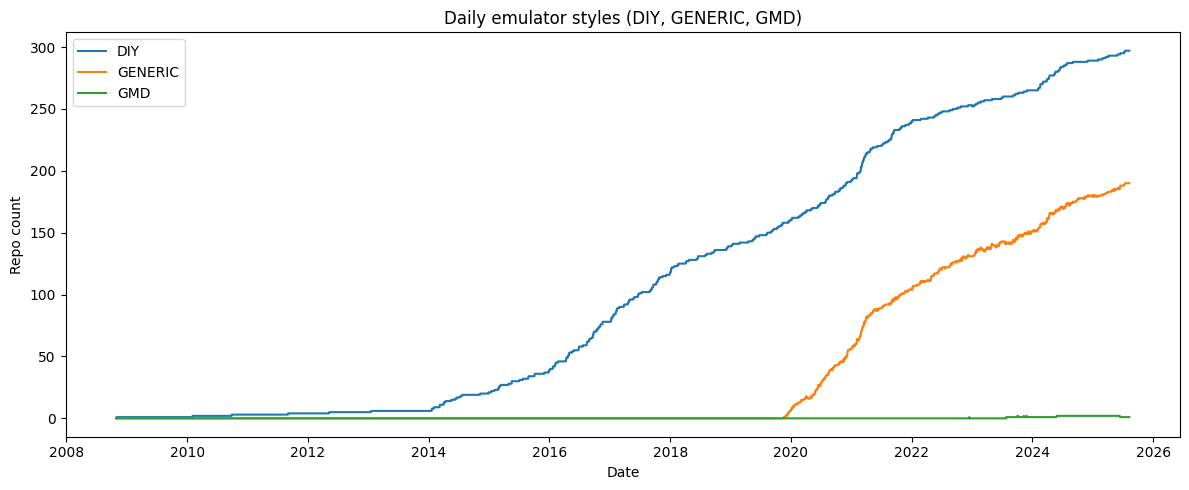

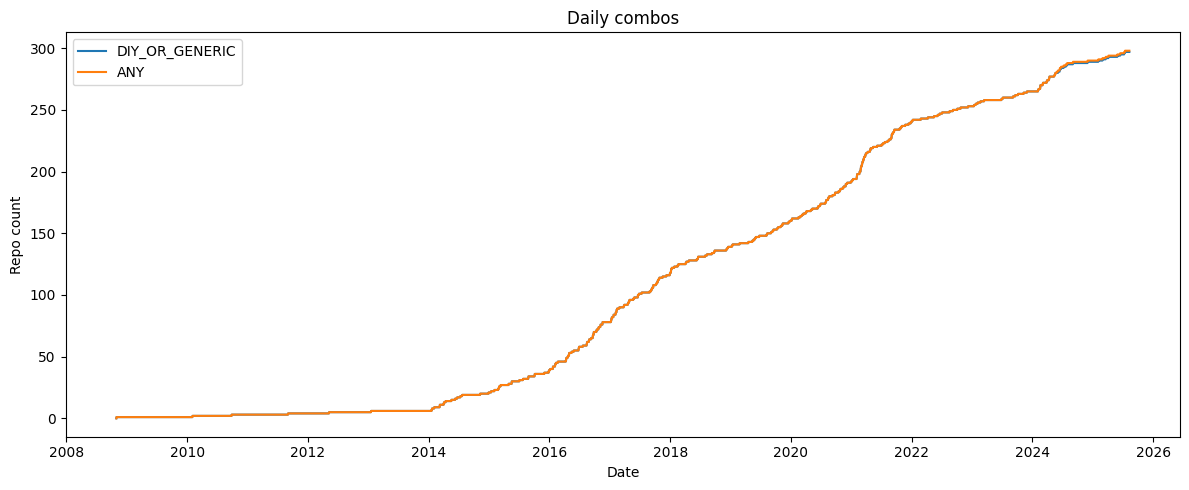

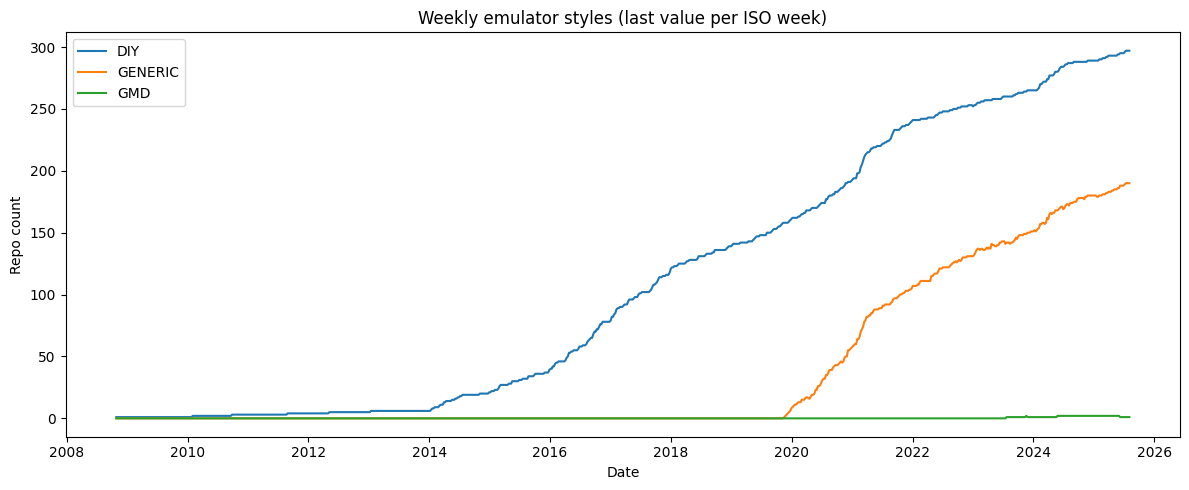

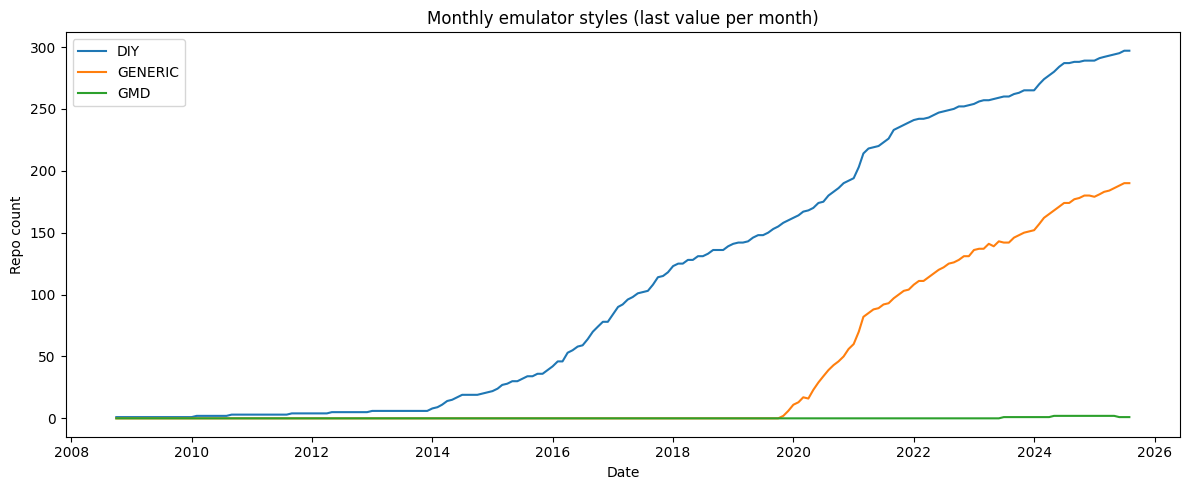

In [2]:
# build_emulator_style_timeline.py
# Group timelines of emulator styles across repos (V3.1 miner-compatible).
# Honors "empty_gaps" from miner outputs by carving those periods out so counts
# do not attribute any style during detection gaps/removals.
#
# Inputs (rglob):  C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\mineV3.1\**\*.emulator_timeline.json
# Outputs:         C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\*.csv / *.json

from __future__ import annotations
import json
from pathlib import Path
from datetime import datetime, timedelta, timezone
from typing import Dict, List, Set, Tuple, Optional

# -----------------------------
# CONFIG — adjust if needed
# -----------------------------
BASE_FOLDER  = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2")
INPUT_MINE   = BASE_FOLDER / "mineV3.1"   # ← rglob in subfolders supported
OUTPUT_GROUP = BASE_FOLDER / "Group"

# Plot behavior
SHOW_PLOTS = True
SAVE_PLOTS = False

# Styles tracked
STYLES = ["DIY", "GENERIC", "GMD"]

# Combined buckets
COMBOS = {
    "DIY_OR_GENERIC": {"DIY", "GENERIC"},
    "ANY": set(STYLES),
}

# Respect miner-detected gaps (recommended = True)
HONOR_EMPTY_GAPS = True

# -----------------------------
# Helpers
# -----------------------------
def parse_iso(dt: Optional[str]) -> Optional[datetime]:
    """Parse ISO; handle 'Z' and no-tz. Return naive UTC."""
    if not dt:
        return None
    s = dt.replace("Z", "+00:00")
    try:
        d = datetime.fromisoformat(s)
    except Exception:
        try:
            d = datetime.strptime(dt.split(".")[0].replace("Z", ""), "%Y-%m-%dT%H:%M:%S")
        except Exception:
            return None
    return d.astimezone(timezone.utc).replace(tzinfo=None) if d.tzinfo else d

def label_to_datetime(label: str) -> datetime:
    """
    Accept 'YYYY-MM-DD', 'YYYY-Www', or 'YYYY-MM' and return a datetime.
    Weeks return Monday of the ISO week; months return first day of month.
    """
    try:
        return datetime.fromisoformat(label)
    except ValueError:
        pass
    if "-W" in label:  # ISO week like '2008-W44'
        y, w = label.split("-W")
        return datetime.fromisocalendar(int(y), int(w), 1)
    try:
        return datetime.strptime(label, "%Y-%m")
    except ValueError:
        pass
    raise ValueError(f"Unsupported date label: {label!r}")

def daterange(start: datetime, end_inclusive: datetime):
    cur = start
    one = timedelta(days=1)
    while cur <= end_inclusive:
        yield cur
        cur += one

def safe_mkdir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def load_repo_jsons(root: Path) -> List[Dict]:
    """Load mined JSONs from root and subfolders (rglob)."""
    items: List[Dict] = []
    if not root.exists():
        return items
    for p in root.rglob("*.emulator_timeline.json"):
        try:
            with p.open("r", encoding="utf-8") as f:
                items.append(json.load(f))
        except Exception as e:
            print(f"[warn] could not parse {p}: {e}")
    return items

# -----------------------------
# Gap extraction & carving
# -----------------------------
def extract_gap_intervals(repo_data: Dict, cutoff_dt: Optional[datetime]) -> List[Tuple[datetime, datetime]]:
    """
    Read miner's detection-gap list. Supports multiple field names for robustness:
      - Preferred: repo_data["empty_gaps"] : [{"start_date": "...", "end_date_exclusive": "...", ...}, ...]
      - Fallbacks per item: "start"|"start_date"|"from", "end"|"end_date"|"end_date_exclusive"|"to"
    Any open-ended gap (end None) is closed at cutoff_dt if available; otherwise dropped.
    Returns sorted, non-overlapping list of [start, end) gaps.
    """
    raw = repo_data.get("empty_gaps") or repo_data.get("detection_gaps") or []
    gaps: List[Tuple[datetime, datetime]] = []
    for g in raw:
        gs = parse_iso(g.get("start") or g.get("start_date") or g.get("from"))
        ge = parse_iso(g.get("end") or g.get("end_date") or g.get("end_date_exclusive") or g.get("to"))
        if gs is None:
            continue
        if ge is None:
            if cutoff_dt is None:
                # Can't resolve open-ended gap without cutoff; skip conservatively
                continue
            ge = cutoff_dt
        if ge <= gs:
            continue
        gaps.append((gs, ge))

    if not gaps:
        return []

    # Merge overlapping/adjacent gaps for simpler carving
    gaps.sort(key=lambda x: x[0])
    merged: List[Tuple[datetime, datetime]] = []
    cur_s, cur_e = gaps[0]
    for s, e in gaps[1:]:
        if s <= cur_e:  # overlap/adjacent
            cur_e = max(cur_e, e)
        else:
            merged.append((cur_s, cur_e))
            cur_s, cur_e = s, e
    merged.append((cur_s, cur_e))
    return merged

def subtract_gaps_from_interval(a: datetime, b: Optional[datetime], gaps: List[Tuple[datetime, datetime]]) -> List[Tuple[datetime, datetime]]:
    """
    Subtract a list of [g0,g1) gaps from a single base interval [a,b).
    Returns a list of remaining [start,end) fragments (may be empty).
    If b is None, treat as open; here we simply drop such intervals (no cutoff).
    """
    if b is None or b <= a:
        return []
    # Start with the whole interval, chop out overlaps
    parts = [(a, b)]
    for g0, g1 in gaps:
        if g1 <= a or g0 >= b:
            continue  # no overlap
        new_parts: List[Tuple[datetime, datetime]] = []
        for p0, p1 in parts:
            if g1 <= p0 or g0 >= p1:
                new_parts.append((p0, p1))  # no overlap with this part
                continue
            # overlap: keep left piece if any
            if p0 < g0:
                new_parts.append((p0, min(g0, p1)))
            # keep right piece if any
            if g1 < p1:
                new_parts.append((max(g1, p0), p1))
        parts = [(x0, x1) for (x0, x1) in new_parts if x1 > x0]
        if not parts:
            break
    return parts

# -----------------------------
# Interval construction
# -----------------------------
def build_intervals_for_repo(repo_data: Dict) -> List[Tuple[datetime, Optional[datetime], Set[str]]]:
    """
    Build piecewise-constant style intervals (right-open), then carve out miner-detected gaps.
    Returns list of (start, end_exclusive_or_None, styles_set).
    """
    timeline = repo_data.get("timeline", []) or []
    cutoff_dt = parse_iso(repo_data.get("cutoff_date"))
    known = set(STYLES)

    # Collect (date, styles_set) ignoring empty styles (miner suppresses those in timeline)
    points: List[Tuple[datetime, Set[str]]] = []
    for row in timeline:
        d = parse_iso(row.get("date"))
        st = set(row.get("styles") or []) & known
        if d is None:
            continue
        # keep rows even if st is empty? timeline shouldn’t have them; but be safe:
        if not st:
            continue
        points.append((d, st))

    # Sort & coalesce identical consecutive styles (ignore automation-only flips)
    points.sort(key=lambda x: x[0])
    coalesced: List[Tuple[datetime, Set[str]]] = []
    for d, st in points:
        if not coalesced or st != coalesced[-1][1]:
            coalesced.append((d, st))

    if not coalesced:
        return []

    # Base intervals [start, next_start) and last extended to cutoff (if present)
    base_intervals: List[Tuple[datetime, Optional[datetime], Set[str]]] = []
    for i, (sd, st) in enumerate(coalesced):
        ed = coalesced[i + 1][0] if i + 1 < len(coalesced) else cutoff_dt
        base_intervals.append((sd, ed, st))

    if HONOR_EMPTY_GAPS:
        # Fetch merged [gap_start, gap_end) list and carve intervals
        gaps = extract_gap_intervals(repo_data, cutoff_dt)
        if gaps:
            carved: List[Tuple[datetime, Optional[datetime], Set[str]]] = []
            for sd, ed, st in base_intervals:
                for x0, x1 in subtract_gaps_from_interval(sd, ed, gaps):
                    carved.append((x0, x1, st))
            # Sort by start time just in case
            carved.sort(key=lambda t: t[0])
            return carved

    return base_intervals

# -----------------------------
# Aggregation
# -----------------------------
def compute_global_date_bounds(all_intervals: List[List[Tuple[datetime, Optional[datetime], Set[str]]]]) -> Tuple[Optional[datetime], Optional[datetime]]:
    """
    Compute inclusive global bounds. End bound uses (end - 1 day) for right-open intervals.
    """
    min_d: Optional[datetime] = None
    max_d: Optional[datetime] = None
    for intervals in all_intervals:
        for (s, e, _styles) in intervals:
            if min_d is None or s < min_d:
                min_d = s
            candidate = (e - timedelta(days=1)) if e else s
            if max_d is None or candidate > max_d:
                max_d = candidate
    return min_d, max_d

def styles_active_on_date(intervals: List[Tuple[datetime, Optional[datetime], Set[str]]], day: datetime) -> Set[str]:
    """
    Return the style set active on a given day for a repo, or empty set if none.
    Intervals are right-open [start, end).
    """
    for (s, e, st) in intervals:
        if s <= day and (e is None or day < e):
            return st
    return set()

def build_daily_counts(repo_jsons: List[Dict]) -> Dict[str, Dict[str, int]]:
    """
    Returns: dict[YYYY-MM-DD][metric] = count
    Metrics include each style in STYLES and COMBOS.
    """
    repo_intervals = [build_intervals_for_repo(j) for j in repo_jsons]
    repo_intervals = [iv for iv in repo_intervals if iv]
    if not repo_intervals:
        return {}

    start_d, end_d = compute_global_date_bounds(repo_intervals)
    if start_d is None or end_d is None:
        return {}

    start_d = datetime(start_d.year, start_d.month, start_d.day)
    end_d   = datetime(end_d.year, end_d.month, end_d.day)

    out: Dict[str, Dict[str, int]] = {}
    for day in daterange(start_d, end_d):
        day_key = day.date().isoformat()
        counts = {s: 0 for s in STYLES}
        for combo_name in COMBOS.keys():
            counts[combo_name] = 0

        for iv in repo_intervals:
            st = styles_active_on_date(iv, day)  # empty during carved gaps
            for s in STYLES:
                if s in st:
                    counts[s] += 1
            for combo_name, combo_set in COMBOS.items():
                if st & combo_set:
                    counts[combo_name] += 1

        out[day_key] = counts
    return out

def write_csv(path: Path, rows: Dict[str, Dict[str, int]], columns: List[str]):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as f:
        f.write(",".join(["date"] + columns) + "\n")
        for day in sorted(rows.keys()):
            vals = [str(rows[day].get(col, 0)) for col in columns]
            f.write(",".join([day] + vals) + "\n")

def resample_period(rows: Dict[str, Dict[str, int]], freq: str) -> Dict[str, Dict[str, int]]:
    """
    freq: 'W' (weekly, Mon-based) or 'M' (month label 'YYYY-MM')
    Aggregate by the last daily value observed in the period (stepwise-constant series).
    """
    items = [(datetime.fromisoformat(k), v) for k, v in rows.items()]
    items.sort(key=lambda x: x[0])

    buckets: Dict[str, Dict[str, int]] = {}

    def period_key(d: datetime) -> str:
        if freq == "W":
            iso_year, iso_week, _ = d.isocalendar()
            return f"{iso_year}-W{iso_week:02d}"
        elif freq == "M":
            return f"{d.year}-{d.month:02d}"
        else:
            raise ValueError("Unsupported freq")

    last_seen: Dict[str, Tuple[datetime, Dict[str, int]]] = {}
    for d, vals in items:
        pk = period_key(d)
        last = last_seen.get(pk)
        if (last is None) or (d >= last[0]):
            last_seen[pk] = (d, vals)

    for pk, (_d, vals) in sorted(last_seen.items(), key=lambda x: x[0]):
        buckets[pk] = dict(vals)
    return buckets

def maybe_plot(rows: Dict[str, Dict[str, int]], title: str, series: List[str], save_path: Optional[Path] = None):
    try:
        import matplotlib.pyplot as plt
    except Exception as e:
        print(f"[info] Skipping plots (matplotlib not available): {e}")
        return
    dates = sorted(rows.keys())
    if not dates:
        print("[info] No data to plot.")
        return
    xs = [label_to_datetime(d) for d in dates]  # supports daily, weekly, monthly labels
    plt.figure(figsize=(12, 5))
    for name in series:
        ys = [rows[d].get(name, 0) for d in dates]
        plt.plot(xs, ys, label=name)
    plt.xlabel("Date")
    plt.ylabel("Repo count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if SAVE_PLOTS and save_path is not None:
        plt.savefig(save_path)
        print(f"[ok] Saved {save_path}")
    if SHOW_PLOTS:
        try:
            plt.show()
        except Exception:
            pass
    plt.close()

# -----------------------------
# Main
# -----------------------------
def main():
    safe_mkdir(OUTPUT_GROUP)

    repo_jsons = load_repo_jsons(INPUT_MINE)
    if not repo_jsons:
        print(f"[info] No mined JSONs found under: {INPUT_MINE}")
        return

    daily = build_daily_counts(repo_jsons)
    if not daily:
        print("[info] No timeline intervals found. Nothing to write.")
        return

    cols = STYLES + list(COMBOS.keys())

    # Daily CSV
    daily_csv = OUTPUT_GROUP / "group_counts_daily.csv"
    write_csv(daily_csv, daily, cols)
    print(f"[ok] Wrote {daily_csv}")

    # Weekly / Monthly rollups
    weekly = resample_period(daily, "W")
    weekly_csv = OUTPUT_GROUP / "group_counts_weekly.csv"
    write_csv(weekly_csv, weekly, cols)
    print(f"[ok] Wrote {weekly_csv}")

    monthly = resample_period(daily, "M")
    monthly_csv = OUTPUT_GROUP / "group_counts_monthly.csv"
    write_csv(monthly_csv, monthly, cols)
    print(f"[ok] Wrote {monthly_csv}")

    # Metadata
    meta = {
        "base_folder": str(BASE_FOLDER),
        "input": str(INPUT_MINE),
        "output": str(OUTPUT_GROUP),
        "styles": STYLES,
        "combos": {k: sorted(list(v)) for k, v in COMBOS.items()},
        "honor_empty_gaps": HONOR_EMPTY_GAPS,
        "date_range": {"first": min(daily.keys()), "last": max(daily.keys())},
        "files": {
            "daily_csv": str(daily_csv),
            "weekly_csv": str(weekly_csv),
            "monthly_csv": str(monthly_csv),
        },
    }
    meta_json = OUTPUT_GROUP / "group_counts_meta.json"
    with meta_json.open("w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)
    print(f"[ok] Wrote {meta_json}")

    # Plots
    maybe_plot(daily,   "Daily emulator styles (DIY, GENERIC, GMD)", STYLES,
               OUTPUT_GROUP / "group_counts_daily.png")
    maybe_plot(daily,   "Daily combos", list(COMBOS.keys()),
               OUTPUT_GROUP / "group_counts_daily_combos.png")
    maybe_plot(weekly,  "Weekly emulator styles (last value per ISO week)", STYLES,
               OUTPUT_GROUP / "group_counts_weekly.png")
    maybe_plot(monthly, "Monthly emulator styles (last value per month)", STYLES,
               OUTPUT_GROUP / "group_counts_monthly.png")

if __name__ == "__main__":
    main()


## State Machine

In [11]:
# summarize_emulator_styles_v3.py
# mineV3.0 summary:
# - Avg dwell time (days) for states: DIY, GENERIC, GMD, DIY+GENERIC
# - Most likely and second most likely next transition for each state
#
# Input:  C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\mineV3.0\*.emulator_timeline.json
# Output: C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\emulator_style_summary_v3.csv

from __future__ import annotations
import json
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Set, Tuple, Optional
import csv

# -----------------------------
# Paths
# -----------------------------
BASE_FOLDER  = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2")
INPUT_MINE   = BASE_FOLDER / "mineV3.0"
OUTPUT_GROUP = BASE_FOLDER / "Group"
OUTPUT_CSV   = OUTPUT_GROUP / "emulator_style_summary_v3.csv"

# -----------------------------
# Canonical states (mutually exclusive)
# -----------------------------
STATE_LABELS = ["DIY", "GENERIC", "GMD", "DIY+GENERIC"]

def label_for_styles(st: Set[str]) -> Optional[str]:
    """Map a set of styles to one of our four canonical states, else None."""
    if st == {"DIY"}:
        return "DIY"
    if st == {"GENERIC"}:
        return "GENERIC"
    if st == {"GMD"}:
        return "GMD"
    if st == {"DIY", "GENERIC"}:
        return "DIY+GENERIC"
    # Ignore anything else (empty set or unexpected combos)
    return None

# -----------------------------
# Helpers
# -----------------------------
def safe_mkdir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def parse_iso(dt: Optional[str]) -> Optional[datetime]:
    """Parse ISO 8601; handle 'Z' and missing timezone. Return naive UTC."""
    if not dt:
        return None
    s = dt.replace("Z", "+00:00")
    try:
        d = datetime.fromisoformat(s)
    except Exception:
        try:
            d = datetime.strptime(dt.split(".")[0].replace("Z", ""), "%Y-%m-%dT%H:%M:%S")
        except Exception:
            return None
    if d.tzinfo is None:
        return d
    return d.astimezone(timezone.utc).replace(tzinfo=None)

def load_repo_jsons(root: Path) -> List[Dict]:
    items = []
    if not root.exists():
        return items
    for p in root.glob("*.emulator_timeline.json"):
        try:
            with p.open("r", encoding="utf-8") as f:
                items.append(json.load(f))
        except Exception as e:
            print(f"[warn] could not parse {p.name}: {e}")
    return items

def build_intervals_for_repo(repo_data: Dict) -> List[Tuple[datetime, Optional[datetime], Set[str]]]:
    """
    Return piecewise-constant intervals:
      [(start_date, end_date_exclusive_or_None, {styles})]
    Coalesce repeated consecutive style-sets.
    """
    tl = repo_data.get("timeline", [])
    points: List[Tuple[datetime, Set[str]]] = []
    for e in tl:
        d = parse_iso(e.get("date"))
        st = set(e.get("styles") or [])
        if d is not None:
            points.append((d, st))

    if not points:
        return []

    points.sort(key=lambda x: x[0])

    # Coalesce consecutive duplicates
    coalesced: List[Tuple[datetime, Set[str]]] = []
    for d, st in points:
        if not coalesced or st != coalesced[-1][1]:
            coalesced.append((d, st))
        # else exact duplicate set at later date: ignore

    intervals: List[Tuple[datetime, Optional[datetime], Set[str]]] = []
    for i, (start_d, st) in enumerate(coalesced):
        end_d = coalesced[i + 1][0] if i + 1 < len(coalesced) else None
        intervals.append((start_d, end_d, st))
    return intervals

# -----------------------------
# Metrics
# -----------------------------
def accumulate_dwell_and_transitions(
    intervals: List[Tuple[datetime, Optional[datetime], Set[str]]],
    dwell_days: Dict[str, List[float]],
    transitions: Dict[str, Dict[str, int]],
):
    """
    - Add dwell durations (days) for CLOSED intervals per canonical state.
    - Count transitions from state A to state B (where both A and B are canonical).
    """
    # Dwell
    for (s, e, st) in intervals:
        src = label_for_styles(st)
        if src is None:
            continue
        if e is None:
            # Open-ended final interval: exclude from dwell
            continue
        d_days = (e - s).days
        if d_days >= 0:
            dwell_days[src].append(float(d_days))

    # Transitions
    for i in range(len(intervals) - 1):
        s1, e1, st1 = intervals[i]
        s2, _,  st2 = intervals[i + 1]
        src = label_for_styles(st1)
        dst = label_for_styles(st2)
        if src is None or dst is None:
            continue
        transitions[src][dst] = transitions[src].get(dst, 0) + 1

def top_two_transitions(counts: Dict[str, int]) -> List[Tuple[str, float]]:
    """
    Return top two (state, pct) pairs based on counts. Percentages sum to 100% across all destinations.
    """
    total = sum(counts.values())
    if total == 0:
        return []
    # Sort by count desc, then by state name for stability
    items = sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))
    result = []
    for state, c in items[:2]:
        pct = 100.0 * c / total
        result.append((state, pct))
    return result

# -----------------------------
# Main
# -----------------------------
def main():
    safe_mkdir(OUTPUT_GROUP)

    repo_jsons = load_repo_jsons(INPUT_MINE)
    if not repo_jsons:
        print(f"[info] No mined JSONs found under: {INPUT_MINE}")
        # Write header only
        with OUTPUT_CSV.open("w", newline="", encoding="utf-8") as f:
            w = csv.writer(f)
            w.writerow([
                "state",
                "avg_dwell_days",
                "most_likely_next",
                "most_likely_next_pct",
                "second_most_likely_next",
                "second_most_likely_next_pct",
                "n_dwell_intervals",
                "n_outgoing_transitions"
            ])
        print(f"[ok] Wrote empty {OUTPUT_CSV}")
        return

    # Build intervals
    all_intervals = []
    for j in repo_jsons:
        iv = build_intervals_for_repo(j)
        if iv:
            all_intervals.append(iv)

    # Accumulators
    dwell_days: Dict[str, List[float]] = {s: [] for s in STATE_LABELS}
    transitions: Dict[str, Dict[str, int]] = {s: {} for s in STATE_LABELS}

    for iv in all_intervals:
        accumulate_dwell_and_transitions(iv, dwell_days, transitions)

    # Write summary CSV
    with OUTPUT_CSV.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow([
            "state",
            "avg_dwell_days",
            "most_likely_next",
            "most_likely_next_pct",
            "second_most_likely_next",
            "second_most_likely_next_pct",
            "n_dwell_intervals",
            "n_outgoing_transitions"
        ])

        for state in STATE_LABELS:
            dw = dwell_days[state]
            avg_dwell = (sum(dw) / len(dw)) if dw else 0.0
            out_counts = transitions[state]
            top2 = top_two_transitions(out_counts)
            ml_state, ml_pct = (top2[0][0], top2[0][1]) if len(top2) >= 1 else ("", 0.0)
            snd_state, snd_pct = (top2[1][0], top2[1][1]) if len(top2) >= 2 else ("", 0.0)

            w.writerow([
                state,
                f"{avg_dwell:.2f}",
                ml_state if not ml_state else f"{state} To {ml_state}",
                f"{ml_pct:.1f}%",
                snd_state if not snd_state else f"{state} To {snd_state}",
                f"{snd_pct:.1f}%",
                len(dw),
                sum(out_counts.values())
            ])

    print(f"[ok] Wrote {OUTPUT_CSV}")

if __name__ == "__main__":
    main()


[ok] Wrote C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\Group\emulator_style_summary_v3.csv
